In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

model = joblib.load("../models/final_gradient_boosting.pkl")

X_train = pd.read_csv("../data/X_train.csv")

In [2]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
11,playlist_entries,0.565937
13,stability_score,0.390857
6,rank_volatility,0.019892
5,rank_range,0.009022
7,avg_daily_rank_change,0.008060
1,worst_rank,0.002190
12,days_to_peak,0.001567
2,avg_rank,0.000956
4,rank_improvement,0.000668
9,avg_popularity,0.000374


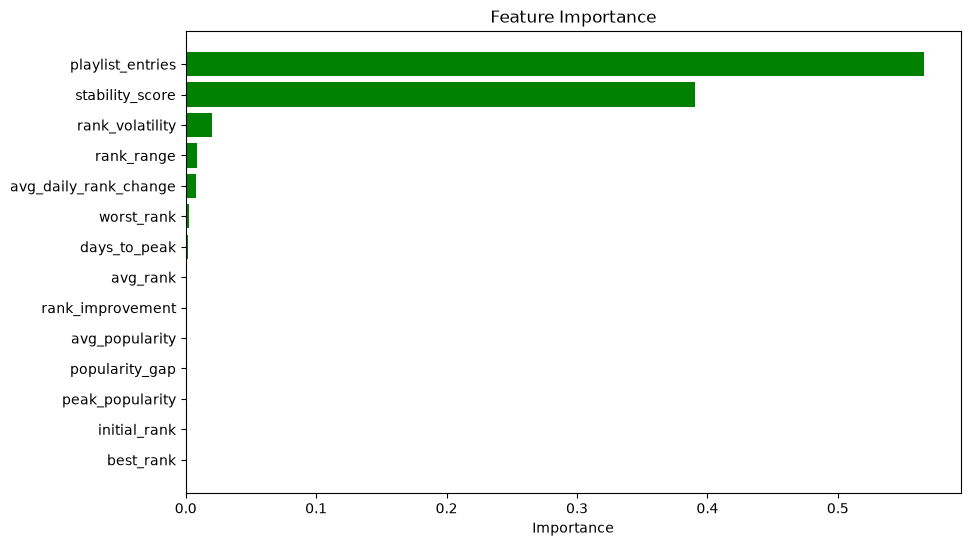

In [3]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"],
    color="green"
)

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [4]:
top10 = importance.head(10)

top10

,Feature,Importance
11,playlist_entries,0.565937
13,stability_score,0.390857
6,rank_volatility,0.019892
5,rank_range,0.009022
7,avg_daily_rank_change,0.008060
1,worst_rank,0.002190
12,days_to_peak,0.001567
2,avg_rank,0.000956
4,rank_improvement,0.000668
9,avg_popularity,0.000374


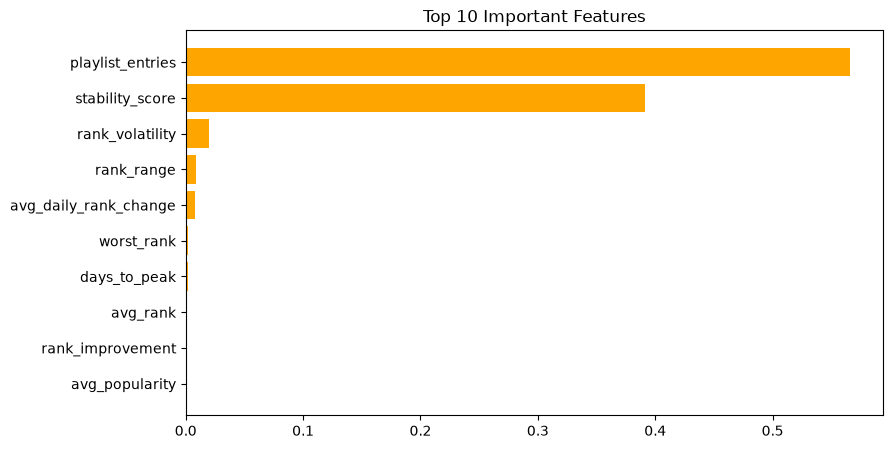

In [5]:
plt.figure(figsize=(9,5))

plt.barh(
    top10["Feature"],
    top10["Importance"],
    color="orange"
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

### Observation

The Gradient Boosting model identifies playlist_entries and stability_score as the two most influential features for predicting playlist survival. These features contribute far more than the remaining variables, indicating that songs appearing frequently in the playlist and maintaining stable chart performance are much more likely to remain on the Spotify Top 50 for longer periods. Features such as rank_volatility, rank_range, and average daily rank change also provide useful predictive information, while popularity-related metrics have comparatively smaller influence.

### Business Insight

The analysis suggests that consistent chart performance is more important than short-term popularity. Songs that repeatedly appear in the playlist and experience stable rankings tend to have significantly longer playlist lifetimes. Record labels can use these insights to focus promotional strategies on maintaining long-term engagement rather than only achieving high initial chart positions.

In [6]:
importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)